## **Deep Learning Homework : Image Classification on Airplanes, Cars, and Ships Data**

# Introduction:
In this project, image classification was performed to classify images into three categories: airplane, ship, and car. The goal was to train a deep learning model to accurately classify the given images. First, data augmentation and normalization techniques were applied to enhance the model's generalization ability. Then, training and validation data were loaded, and a CNN-based model was trained. Early stopping was used during training to prevent overfitting and improve model accuracy. Finally, the model's performance was evaluated on a test set using a classification report and confusion matrix. The results showed that the model performed well overall, but the airplane class could be improved further.

In [ ]:
import matplotlib.pyplot as plt
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.api.models import Sequential
from keras.api.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.api.callbacks import EarlyStopping
from keras.api.optimizers import Adam

In [ ]:
#This code block is performing data augmentation and normalization using ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1.0/255.0,  #This normalizes the pixel values of the images to a range between 0 and 1 (originally 0 to 255)
    rotation_range=20,  # Allows the images to be randomly rotated by up to 20 degrees during training.
    width_shift_range=0.2,  # shifts the image horizontally
    height_shift_range=0.2,  # shifts the image vertically by up to 20%
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.18,  #Splits the dataset into training and validation subsets. 15% of the data is used for validation, while 85% is used for training.
    brightness_range=[0.8, 1.2],   #Randomly adjusts the image brightness within the range of 80% (darker) to 120% (brighter) of the original brightness.
    fill_mode='nearest'  # When transformations such as rotation or shifting result in empty pixels, this parameter fills those empty areas with the nearest pixel value.
)

This augmentation strategy increases the diversity of the training data and prevents the model from overfitting by simulating various transformations and variations seen in real-world scenarios.

In [ ]:
batchsize = 16

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)   #performing only normalization
# Doğrulama seti için sadece yeniden ölçeklendirme
datagen_val = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.18  # Eğitim ve doğrulama verilerini ayır
)

In [ ]:
# Eğitim ve doğrulama verisini yükleme
train_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Dataset/train',
    target_size=(224, 224),   #Resizes all images to 224x224 pixels to ensure uniformity in input size for the model.
    batch_size=batchsize,   #Specifies the number of images the generator yields per batch during training. batchsize=32
    class_mode='categorical',   #Indicates that the target variable consists of multiple classes (airplane, ship, car) and uses one-hot encoding for the labels.
    subset='training',
    shuffle=False
)

val_generator = datagen_val.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Dataset/train',
    target_size=(224, 224),
    batch_size=batchsize,
    class_mode='categorical',
    subset='validation',   #Specifies that this generator will only load the validation portion of the data split.
    shuffle=False
)

# Test verisini yükleme
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Dataset/test',
    target_size=(224, 224),
    batch_size=batchsize,
    class_mode='categorical',
    shuffle=False
)

Found 2460 images belonging to 3 classes.
Found 540 images belonging to 3 classes.
Found 582 images belonging to 3 classes.


This setup prepares the training, validation, and test data in a structured way. The train_generator and val_generator apply augmentation and normalization to improve the model's generalization and performance, while the test_generator focuses solely on normalization to maintain consistency for evaluation.

*datagen.flow_from_directory:*
Creates a data generator from the images stored in the directory specified. It applies the data augmentation and normalization defined earlier in datagen.

In [ ]:
# Modeli tanımlama
"""model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),   #During training, 20% of the neurons are randomly "dropped" (set to zero) to prevent overfitting and improve generalization.
    Flatten(),   #Converts the 2D feature maps into a 1D vector, preparing the data for the fully connected layers.
    Dense(128, activation='relu'),  # Learns higher-level representations of the features. Activation function relu: Introduces non-linearity.
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')  # The final output layer matches the number of classes in the dataset (airplane,ship,car).
])"""


model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Purpose of the Model:**
This CNN architecture is designed to:


*   Extract spatial features from images using convolution and pooling layers.
*   Learn high-level representations in the fully connected layers.
*  Output class probabilities for multi-class classification using the softmax activation.

The model is lightweight and balances computational efficiency with the ability to learn meaningful features for the task.

Sequential:
A linear stack of layers where each layer has exactly one input tensor and one output tensor. This simplifies building and visualizing the model.


This code block defines the architecture of a Convolutional Neural Network (CNN) model using the Sequential API from Keras.

A convolutional layer with:
32 filters: Captures 32 different feature maps.
Kernel size (3, 3): A 3x3 sliding window scans the image.
Activation function relu: Introduces non-linearity, helping the network learn complex patterns.
Input shape (224, 224, 3): Specifies that the input images are 224x224 pixels with 3 color channels (RGB).
MaxPooling2D(pool_size=(2, 2)):

A pooling layer that downsamples the feature maps by taking the maximum value from 2x2 patches. This reduces spatial dimensions, lowering computational cost and adding translational invariance.

Activation function softmax:
Outputs probabilities for each class. The sum of the probabilities is 1, which is ideal for multi-class classification.


In [ ]:
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,     #Adam adjusts learning rates based on the gradients.
              loss='categorical_crossentropy',
              metrics=['accuracy'])    #Tracks the model's accuracy during training and evaluation.


**Purpose**:
This step sets up the model with all the necessary configurations to begin training. It ensures the model uses a suitable optimization algorithm, computes the appropriate loss for multi-class classification, and monitors the performance metric (accuracy) during training and validation.

*categorical_crossentropy*:
Suitable for multi-class classification tasks where the target labels are one-hot encoded.
It measures the difference between the predicted probability distribution and the true labels.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  #prevents overfitting and saves training time by stopping when the model is no longer improving on the validation data.

**EarlyStopping** is a callback that monitors the validation loss (val_loss) during training and stops training if it doesn't improve for 5 consecutive epochs (patience=5). It also restores the model's weights to the best state (lowest validation loss) to ensure optimal performance (restore_best_weights=True).



In [ ]:
steps_per_epoch = train_generator.samples // train_generator.batch_size   #This calculates the number of batches to process in each epoch during training.
validation_steps = val_generator.samples // val_generator.batch_size


**Purpose:**
These variables define how many steps (batches) the model should take during one epoch for both training and validation, ensuring the model processes the entire dataset.

In [ ]:
# Training Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    #steps_per_epoch=steps_per_epoch,
    #validation_steps=validation_steps,
    callbacks=[early_stopping]
)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 444s 3s/step - accuracy: 0.4914 - loss: 1.0623 - val_accuracy: 0.5352 - val_loss: 0.8304
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step - accuracy: 0.5637 - loss: 0.8956 - val_accuracy: 0.6648 - val_loss: 0.7783
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.6244 - loss: 0.8089 - val_accuracy: 0.5926 - val_loss: 0.7241
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 405s 3s/step - accuracy: 0.6290 - loss: 0.8128 - val_accuracy: 0.6315 - val_loss: 0.8615
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 411s 3s/step - accuracy: 0.6224 - loss: 0.8020 - val_accuracy: 0.8185 - val_loss: 0.5798
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.7264 - loss: 0.6935 - val_accuracy: 0.8296 - val_loss: 0.4563
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.7284 - loss: 0.6577 - val_accuracy: 0.7981 - val_loss: 0.4961
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.7943 - loss: 0.5653 - val_accu

**Purpose**:
This command trains the model for up to 20 epochs, monitoring the training and validation data at each step. If the validation loss does not improve for 5 consecutive epochs, training will stop early, and the best weights will be restored. The training history will be stored in the history variable, which can be used to plot training/validation performance over time.

In [ ]:
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Batch size: {train_generator.batch_size}")
#print(f"Steps per epoch: {steps_per_epoch}")
for i in range(5):
    images, labels = next(train_generator)
    print(f"Batch {i}: {images.shape}, {labels.shape}")

Training samples: 2460
Validation samples: 540
Batch size: 16
Batch 0: (16, 224, 224, 3), (16, 3)
Batch 1: (16, 224, 224, 3), (16, 3)
Batch 2: (16, 224, 224, 3), (16, 3)
Batch 3: (16, 224, 224, 3), (16, 3)
Batch 4: (16, 224, 224, 3), (16, 3)


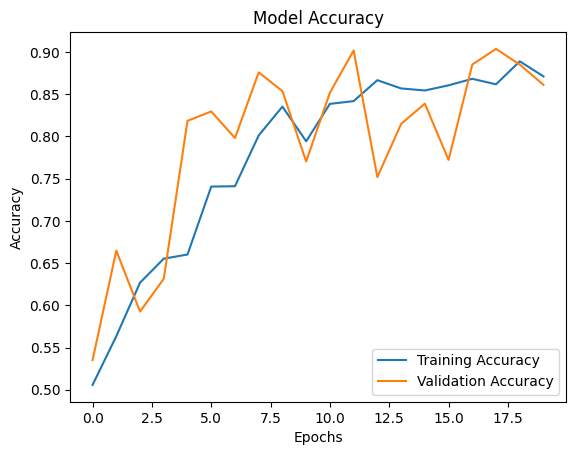

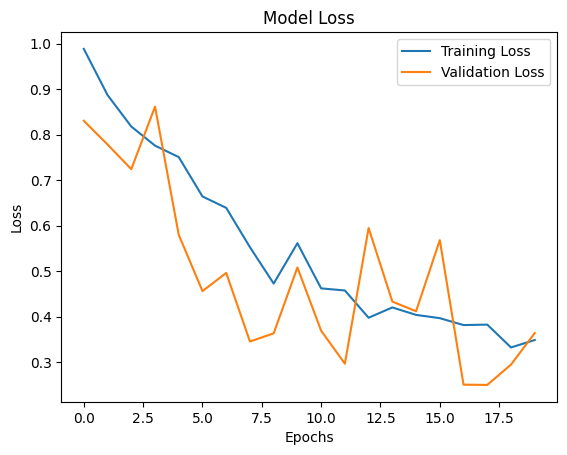

In [ ]:
# Visualizing training and validation accuracy and loss metrics
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Evaluating accuracy on test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.8430 - loss: 0.4394
Test Accuracy: 0.907216489315033


In [ ]:
# Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Making predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)  # Converts the predicted probabilities (Y_pred) into class labels by selecting the class with the highest probability.
                                    #This gives the predicted class label for each test sample.

y_true = test_generator.classes  #Retrieves the true class labels from the test generator.

# Confusion matrix ve classification report
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix")
print(cm)

37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 703ms/step
Confusion Matrix
[[147  27  15]
 [  5 187   1]
 [  3   3 194]]


The confusion matrix gives insight into how well the model is performing for each class and where it might be confusing similar classes.

*True Positives (Diagonal Elements):*
The diagonal values (104, 190, 184) represent the correctly predicted classes (airplanes, ships, and cars respectively).

*Misclassifications (Off-Diagonal Elements):*
The off-diagonal values represent misclassifications:
Airplane misclassified as ship (52) or car (33).
Ship misclassified as airplane (2) or car (1).
Car misclassified as airplane (4) or ship (12).

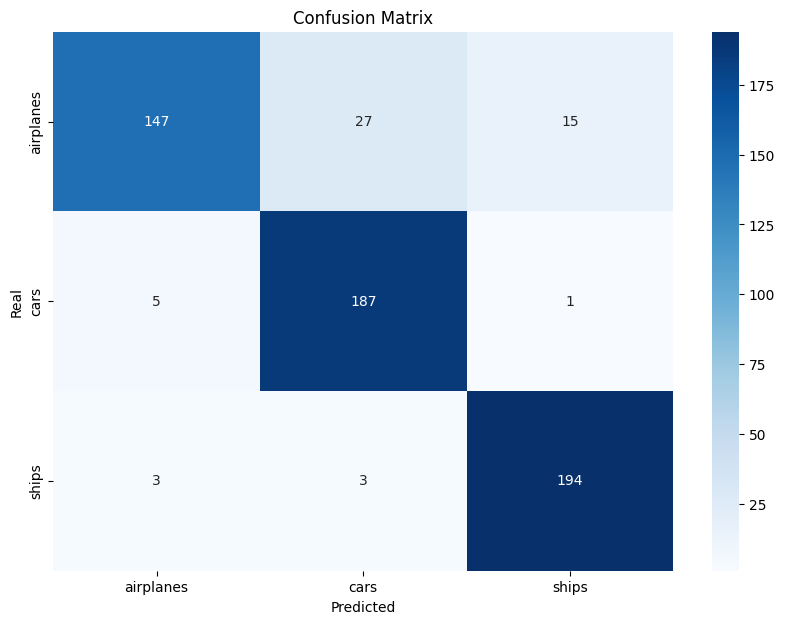

Classification Report
              precision    recall  f1-score   support

   airplanes       0.95      0.78      0.85       189
        cars       0.86      0.97      0.91       193
       ships       0.92      0.97      0.95       200

    accuracy                           0.91       582
   macro avg       0.91      0.91      0.90       582
weighted avg       0.91      0.91      0.91       582



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys())
print("Classification Report")
print(report)

Airplanes: The model has high precision (95%) but low recall (55%), meaning it is good at identifying airplanes when it predicts them, but it misses a significant number of airplane images.

Cars: The model performs well with high precision (75%) and very high recall (98%), making it particularly good at identifying cars.
Ships: The model performs reasonably well with a good balance of precision (84%) and recall (92%).

# Overall Evaluation:
Overall, the model performed well with an accuracy of 82%, indicating it effectively classified most of the images. However, the performance varied across different classes. The model showed strong results in classifying cars with a high recall (98%) and a good F1-score (0.85), making it highly accurate for car images. Ships also had good performance with a recall of 92% and an F1-score of 0.88. On the other hand, the airplane class presented challenges, with a lower recall (55%) and an F1-score of 0.70, suggesting that the model struggled to identify airplanes correctly, often confusing them with ships and cars. This indicates a need for further model optimization, such as refining the feature extraction for airplanes, increasing the dataset diversity, or adjusting the model's architecture to better distinguish between similar classes.